In [1]:
# Run this cell ALONE first in every notebook
!pip install optuna -q
print("Optuna ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 35.5 MB/s eta 0:00:00
Optuna ready.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# BiLSTM — SNIPPET 1: PREPROCESSING + ARCHITECTURE
# Source: Documents 9 + 10 (original BiLSTM with attention implementation)
# MODIFIED: build_bilstm now accepts an explicit `hp` dict instead of the
# global HP — the only change needed to make it reusable across baseline and
# search. Everything else is identical to Documents 9 and 10.
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np, random, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Dropout, Bidirectional,
    GlobalAveragePooling1D, LayerNormalization,
    MultiHeadAttention, Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

DATA_PATH = '/content/'
SEQ_LEN   = 40

DATASET_CONFIG = {
    'FD001': {'rul_threshold': 125, 'multi_condition': False},
    'FD002': {'rul_threshold': 125, 'multi_condition': True},
    'FD003': {'rul_threshold': 125, 'multi_condition': False},
    'FD004': {'rul_threshold': 125, 'multi_condition': True},
}

# Default HP — from Document 10 (used for Phase 0 baseline)
HP_DEFAULT = {
    'hidden'      : 64,
    'num_heads'   : 4,
    'key_dim'     : 32,
    'dropout'     : 0.1,
    'ffn_dim'     : 128,
    'lr'          : 8e-5,
    'batch_size'  : 32,
    'epochs'      : 100,
    'patience_es' : 25,
    'patience_lr' : 8,
    'lr_factor'   : 0.5,
    'min_lr'      : 1e-7,
}

# ── Data loading ──────────────────────────────────────────────────────────────
def load_data(dataset):
    cols     = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
    train_df = pd.read_csv(f"{DATA_PATH}train_{dataset}.txt",
                           sep=r"\s+", header=None)
    train_df.columns = cols
    test_df  = pd.read_csv(f"{DATA_PATH}test_{dataset}.txt",
                           sep=r"\s+", header=None)
    test_df.columns  = cols
    y_test   = pd.read_csv(f"{DATA_PATH}RUL_{dataset}.txt",
                           header=None).values.flatten()
    return train_df, test_df, y_test

# ── Preprocessing: MinMax [0,1] ────────────────────────────────────────────────
def preprocess(train_df, test_df, dataset):
    cfg           = DATASET_CONFIG[dataset]
    max_cycle     = train_df.groupby('id')['cycle'].max().reset_index()
    max_cycle.columns = ['id','max_cycle']
    train_df      = train_df.merge(max_cycle, on='id')
    train_df['RUL'] = (train_df['max_cycle'] -
                       train_df['cycle']).clip(upper=cfg['rul_threshold'])
    train_df.drop(columns=['max_cycle'], inplace=True)
    feature_cols  = [c for c in train_df.columns if c not in ['id','RUL']]
    scaler        = MinMaxScaler(feature_range=(0, 1))
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
    return train_df, test_df, feature_cols

# ── Sequence generation ────────────────────────────────────────────────────────
def create_sequences(df, feature_cols, seq_len):
    X_seqs, y_seqs = [], []
    for eid in df['id'].unique():
        data = df[df['id'] == eid][feature_cols + ['RUL']].values
        for i in range(len(data) - seq_len):
            X_seqs.append(data[i:i+seq_len, :-1])
            y_seqs.append(data[i+seq_len, -1])
    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_seqs, dtype=np.float32))

def create_test_sequences(test_df, feature_cols, seq_len):
    X_test = []
    for eid in test_df['id'].unique():
        ed = test_df[test_df['id'] == eid][feature_cols].values
        if len(ed) < seq_len:
            pad = np.zeros((seq_len - len(ed), ed.shape[1]))
            ed  = np.vstack([pad, ed])
        else:
            ed = ed[-seq_len:]
        X_test.append(ed)
    return np.array(X_test, dtype=np.float32)

# ── Metrics ────────────────────────────────────────────────────────────────────
def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    return float(np.sum(np.where(diff < 0,
                                 np.exp(-diff/13)-1, np.exp(diff/10)-1)))

def report_metrics(name, true, pred):
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)
    print(f"{name:40s} MSE={mse:.3f} RMSE={rmse:.3f} MAE={mae:.3f} NASA={nasa:.1f}")
    return rmse, mae, mse, nasa

# ── Visualization ──────────────────────────────────────────────────────────────
def plot_loss(h, name, ds):
    plt.figure(figsize=(10,5))
    plt.plot(h.history['loss'],     label='Train Loss')
    plt.plot(h.history['val_loss'], label='Val Loss')
    plt.title(f'{name} — Loss vs Epoch ({ds})')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(); plt.show()

def plot_predictions(y_test, pred, name, ds):
    plt.figure(figsize=(14,5))
    plt.plot(y_test, label='Actual RUL', linewidth=2, color='black')
    plt.plot(pred,   label=f'{name} Predicted', linewidth=1.5,
             color='blue', alpha=0.8)
    plt.title(f'Actual vs Predicted RUL — {name} ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('RUL')
    plt.legend(); plt.grid(); plt.show()

def plot_residuals(y_test, pred, name, ds):
    res = y_test - pred
    plt.figure(figsize=(10,4))
    plt.scatter(range(len(res)), res, alpha=0.6, color='steelblue')
    plt.axhline(0, linestyle='--', color='black')
    plt.title(f'Residuals — {name} ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('Residual')
    plt.grid(); plt.show()

def plot_rmse_bar(results_dict, model_name):
    datasets  = list(results_dict.keys())
    rmse_vals = [results_dict[ds]['rmse'] for ds in datasets]
    plt.figure(figsize=(8,5))
    bars = plt.bar(datasets, rmse_vals, color='steelblue', edgecolor='white')
    plt.bar_label(bars, fmt='%.3f', padding=3)
    plt.title(f'{model_name} — Test RMSE Across Datasets')
    plt.ylabel('RMSE'); plt.grid(axis='y'); plt.show()

def plot_rul_dist(train_df, ds):
    plt.figure(figsize=(10,5))
    plt.hist(train_df['RUL'], bins=40, color='steelblue', edgecolor='white')
    plt.title(f'RUL Distribution — {ds}')
    plt.xlabel('RUL'); plt.ylabel('Frequency')
    plt.grid(); plt.show()

# ── BiLSTM model ──────────────────────────────────────────────────────────────
# MODIFIED: accepts explicit `hp` dict instead of global HP.
# Architecture is identical to Document 10 — BiLSTM → MHA → FFN → GAP → FC.
def build_bilstm(seq_len, n_features, hp):
    inputs = Input(shape=(seq_len, n_features))
    x = Bidirectional(LSTM(hp['hidden'], return_sequences=True,
                           recurrent_dropout=0.0))(inputs)
    x = Dropout(hp['dropout'])(x)
    attn = MultiHeadAttention(num_heads=hp['num_heads'],
                               key_dim=hp['key_dim'],
                               dropout=0.05)(x, x)
    x = LayerNormalization()(Add()([x, attn]))
    ffn = Dense(hp['ffn_dim'], activation='relu')(x)
    ffn = Dense(x.shape[-1])(ffn)    # residual: output dim = 2*hidden
    x   = LayerNormalization()(Add()([x, ffn]))
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(hp['dropout'])(x)
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(hp['lr'], clipnorm=1.0),
                  loss=Huber(), metrics=['mae'])
    return model

# ── Verification ───────────────────────────────────────────────────────────────
print("="*60)
print("  BiLSTM ARCHITECTURE")
print("="*60)
_m = build_bilstm(SEQ_LEN, 25, HP_DEFAULT)
_m.summary()
print(f"\n  Input      : (B, {SEQ_LEN}, 25)")
print(f"  BiLSTM     : (B, {SEQ_LEN}, {HP_DEFAULT['hidden']*2})")
print(f"  MHA        : (B, {SEQ_LEN}, {HP_DEFAULT['hidden']*2})")
print(f"  FFN        : (B, {SEQ_LEN}, {HP_DEFAULT['hidden']*2})")
print(f"  GAP        : (B, {HP_DEFAULT['hidden']*2})")
print(f"  Dense(64)  : (B, 64)")
print(f"  Output     : (B, 1)")
del _m

print("\n  Dataset check:")
for ds in ['FD001','FD002','FD003','FD004']:
    tr, te, y = load_data(ds)
    print(f"    {ds}: train={tr.shape}  test={te.shape}  y_test={y.shape}")
print("\n  Snippet 1 ready.\n")

  BiLSTM ARCHITECTURE


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40, 25)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 40, 128)   │     46,080 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 40, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 40, 128)   │     66,048 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 128)   │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 40, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 40, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 40, 128)   │     16,512 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 40, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 153,985 (601.50 KB)

 Trainable params: 153,985 (601.50 KB)

 Non-trainable params: 0 (0.00 B)


  Input      : (B, 40, 25)
  BiLSTM     : (B, 40, 128)
  MHA        : (B, 40, 128)
  FFN        : (B, 40, 128)
  GAP        : (B, 128)
  Dense(64)  : (B, 64)
  Output     : (B, 1)

  Dataset check:
    FD001: train=(20631, 26)  test=(13096, 26)  y_test=(100,)
    FD002: train=(53759, 26)  test=(33991, 26)  y_test=(259,)
    FD003: train=(24720, 26)  test=(16596, 26)  y_test=(100,)
    FD004: train=(61249, 26)  test=(41214, 26)  y_test=(248,)

  Snippet 1 ready.




███████████████████████████████████████████████████████
  BiLSTM BASELINE — Default HP
  hidden=64  num_heads=4  key_dim=32  ffn_dim=128
  lr=8e-05  batch=32  dropout=0.1
███████████████████████████████████████████████████████

███████████████████████████████████████████████████████
  BiLSTM | FD001
███████████████████████████████████████████████████████


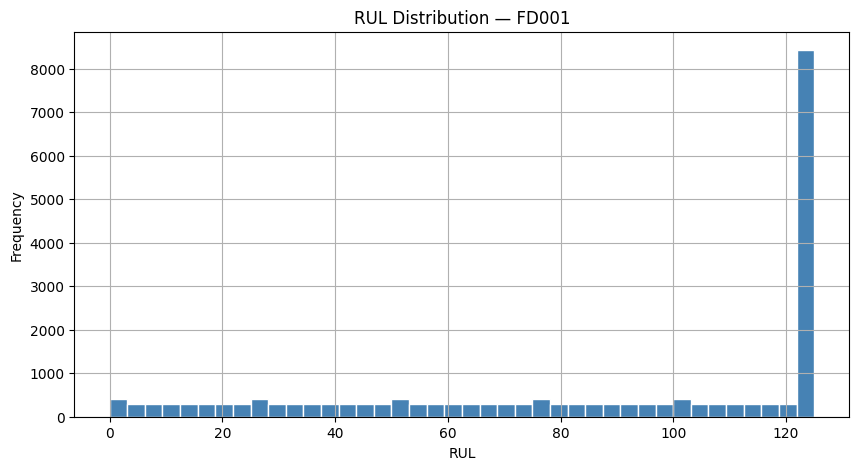

  Train:(13361, 40, 25) Val:(3270, 40, 25) Test:(100, 40, 25)

Epoch 20: ReduceLROnPlateau reducing learning rate to 3.9999998989515007e-05.

Epoch 31: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 39: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.

Epoch 52: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 60: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 68: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.

  Validation:
  BiLSTM                                 MSE=122.536 RMSE=11.070 MAE=7.326 NASA=6531.0
  Test:
  BiLSTM                                 MSE=212.785 RMSE=14.587 MAE=9.943 NASA=369.1


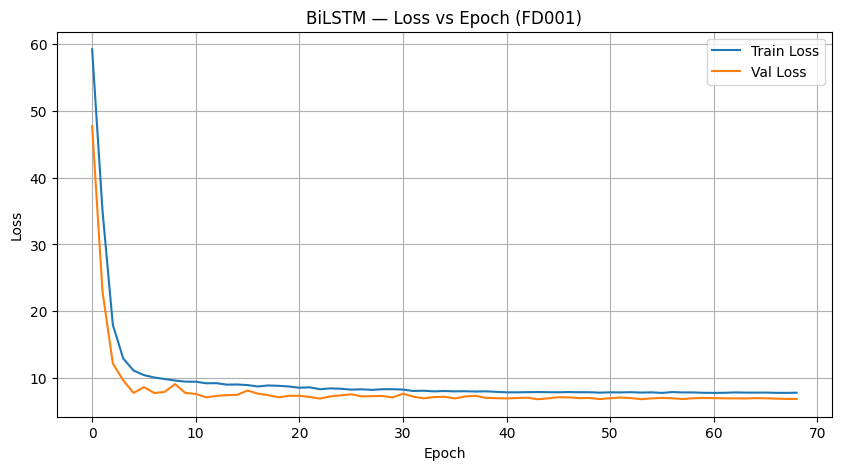

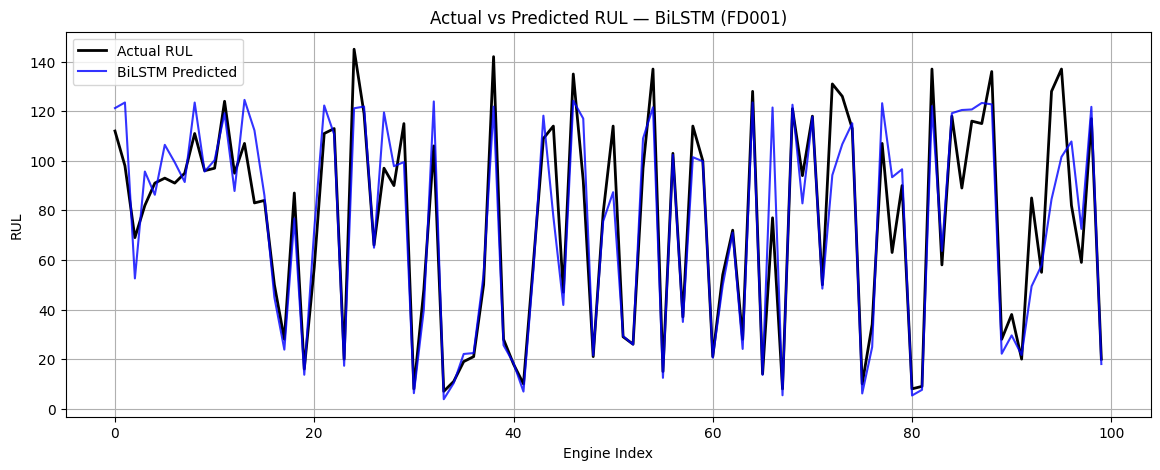

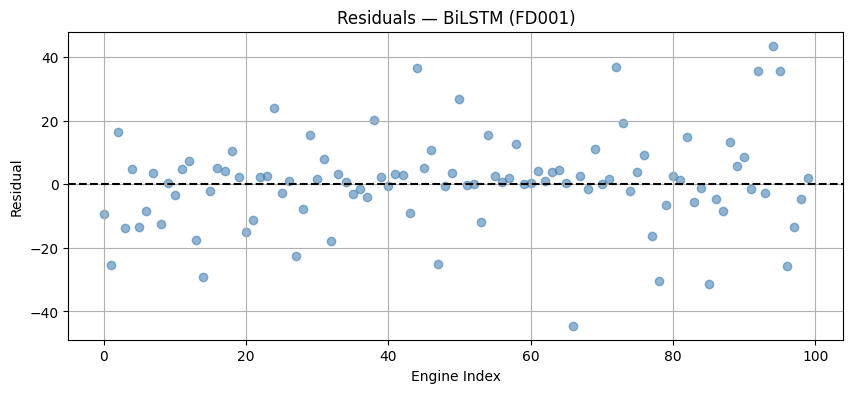


███████████████████████████████████████████████████████
  BiLSTM | FD002
███████████████████████████████████████████████████████


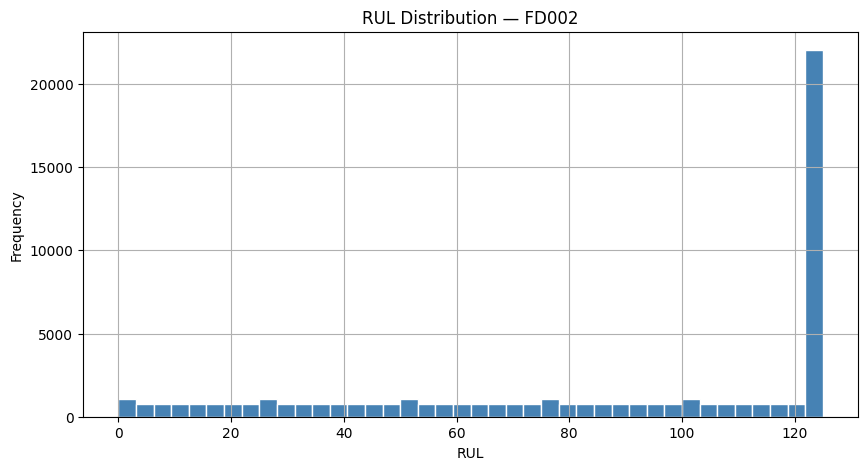

  Train:(35144, 40, 25) Val:(8215, 40, 25) Test:(259, 40, 25)

Epoch 34: ReduceLROnPlateau reducing learning rate to 3.9999998989515007e-05.

Epoch 60: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 68: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.

Epoch 76: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

  Validation:
  BiLSTM                                 MSE=259.081 RMSE=16.096 MAE=11.094 NASA=53881.8
  Test:
  BiLSTM                                 MSE=689.409 RMSE=26.257 MAE=17.810 NASA=7963.6


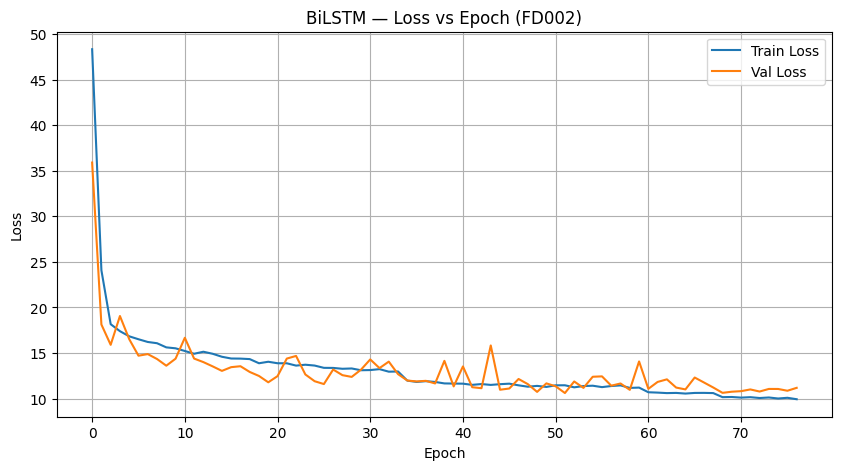

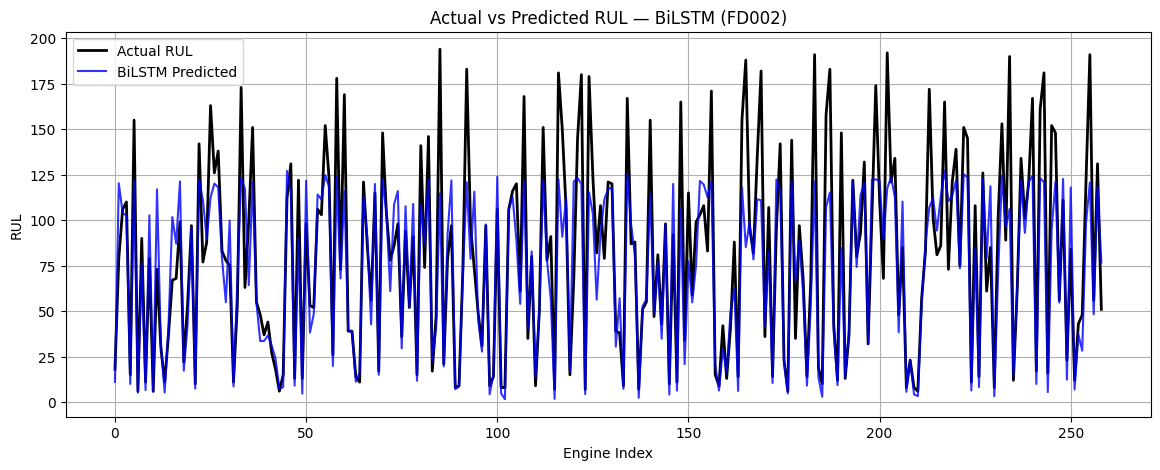

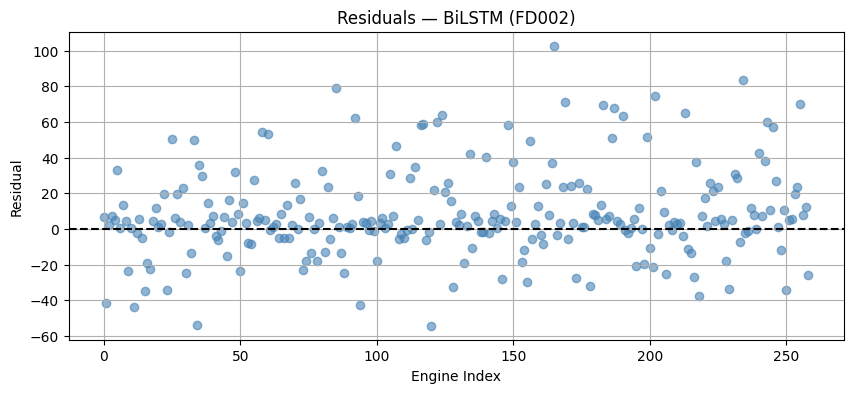


███████████████████████████████████████████████████████
  BiLSTM | FD003
███████████████████████████████████████████████████████


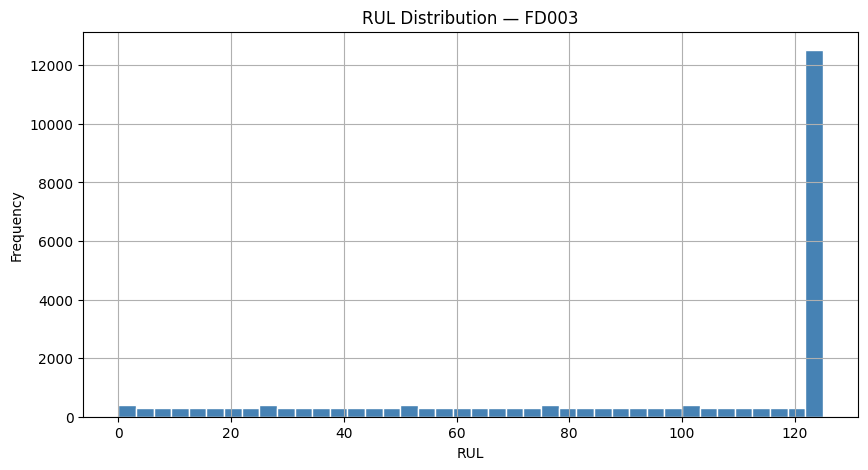

  Train:(16812, 40, 25) Val:(3908, 40, 25) Test:(100, 40, 25)

Epoch 32: ReduceLROnPlateau reducing learning rate to 3.9999998989515007e-05.

Epoch 43: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 51: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.

Epoch 59: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

  Validation:
  BiLSTM                                 MSE=109.298 RMSE=10.455 MAE=6.494 NASA=8048.3
  Test:
  BiLSTM                                 MSE=271.476 RMSE=16.477 MAE=12.031 NASA=481.8


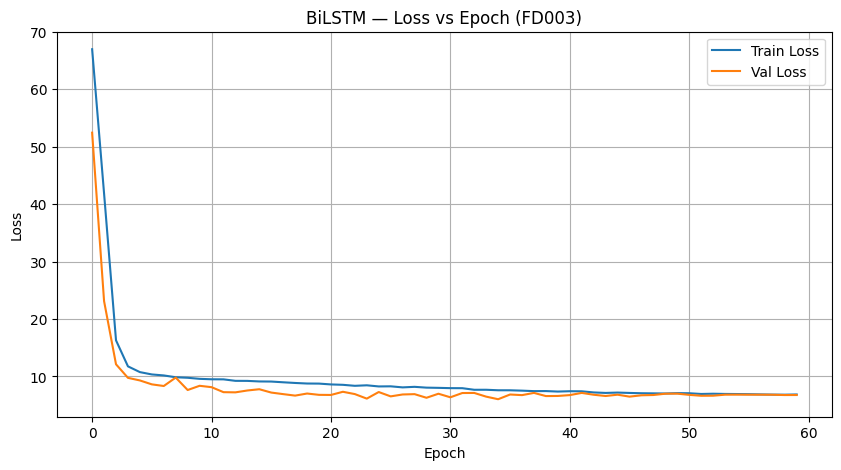

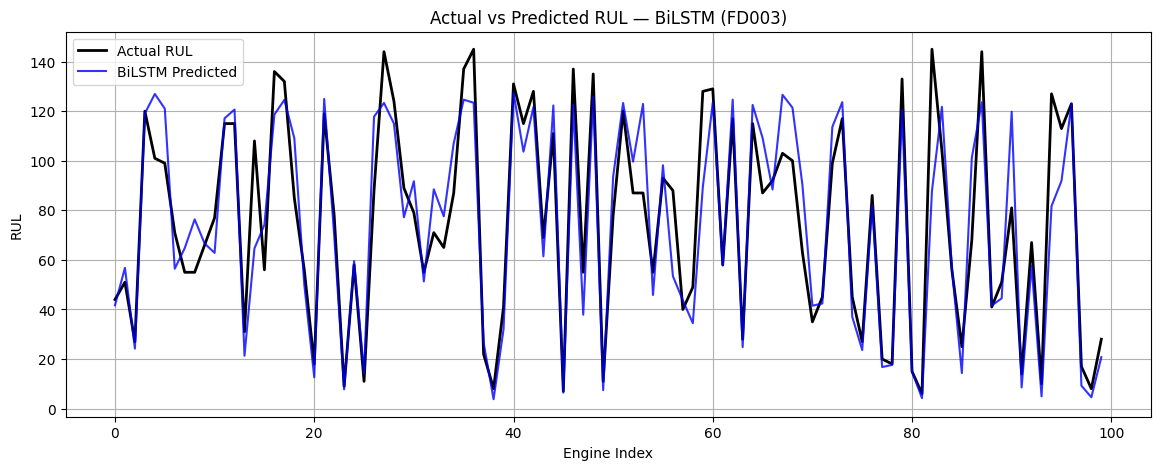

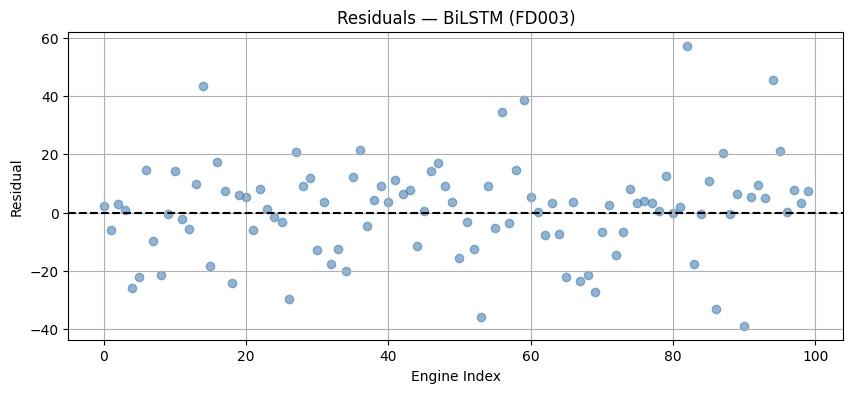


███████████████████████████████████████████████████████
  BiLSTM | FD004
███████████████████████████████████████████████████████


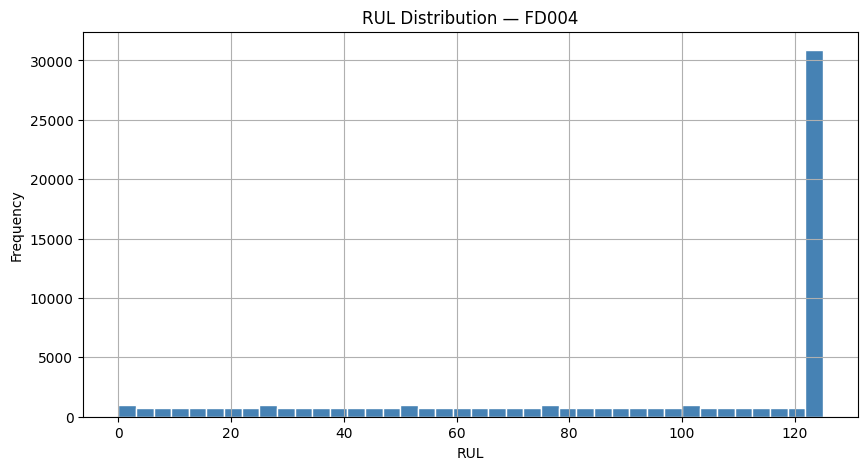

  Train:(41334, 40, 25) Val:(9955, 40, 25) Test:(248, 40, 25)

Epoch 44: ReduceLROnPlateau reducing learning rate to 3.9999998989515007e-05.

Epoch 58: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 66: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.

Epoch 74: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

  Validation:
  BiLSTM                                 MSE=428.562 RMSE=20.702 MAE=13.359 NASA=247907.4
  Test:
  BiLSTM                                 MSE=859.305 RMSE=29.314 MAE=21.301 NASA=8241.0


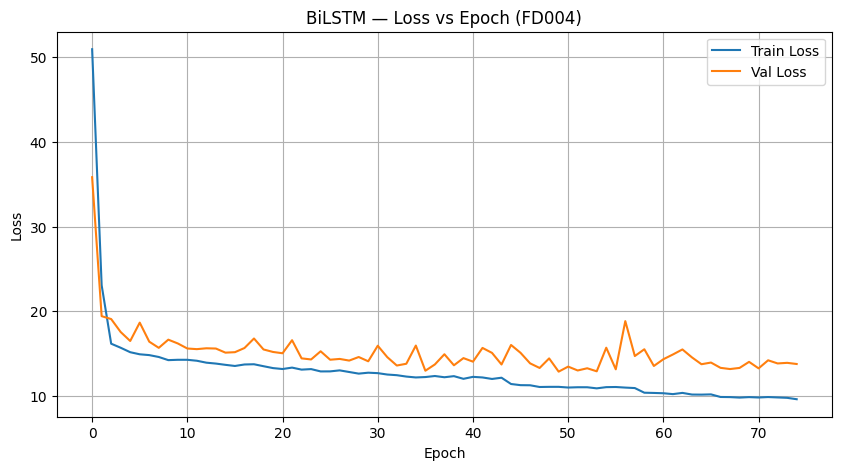

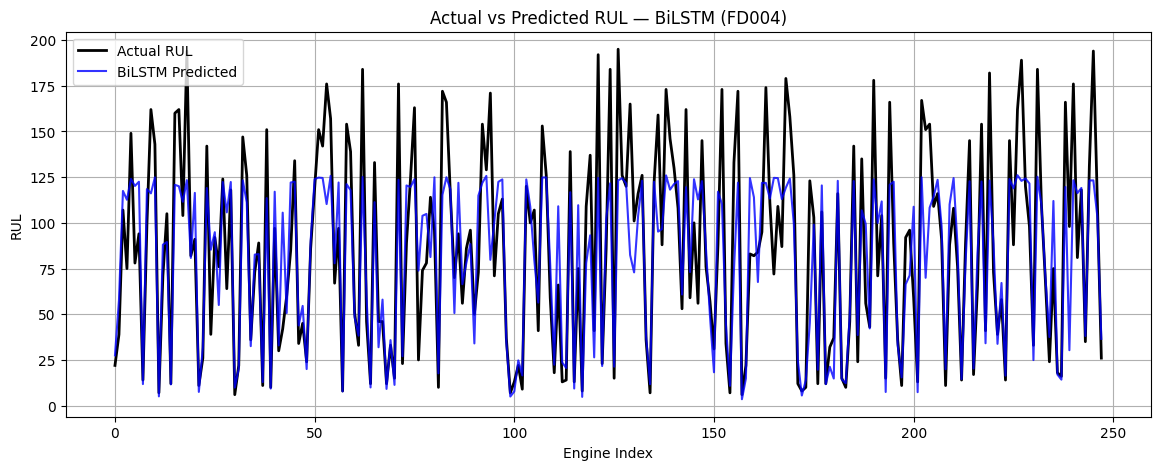

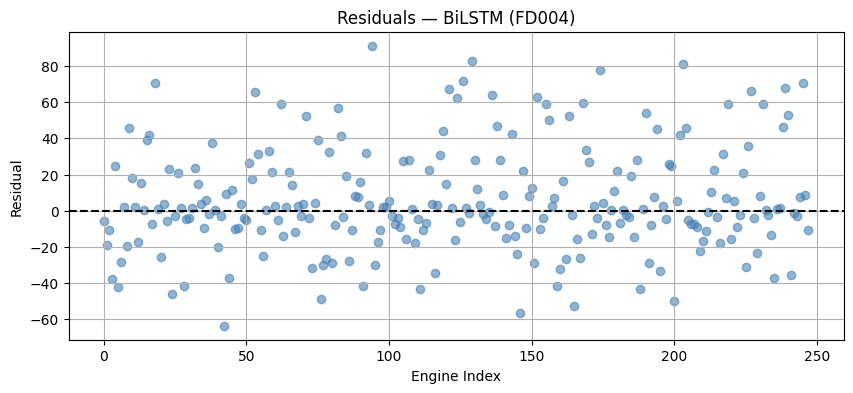


════════════════════════════════════════════════════════════
  BiLSTM BASELINE RESULTS
════════════════════════════════════════════════════════════
Dataset        RMSE      MAE        MSE       NASA
────────── ──────── ──────── ────────── ──────────
FD001        14.587    9.943    212.785      369.1
FD002        26.257   17.810    689.409     7963.6
FD003        16.477   12.031    271.476      481.8
FD004        29.314   21.301    859.305     8241.0

  Average RMSE: 21.659


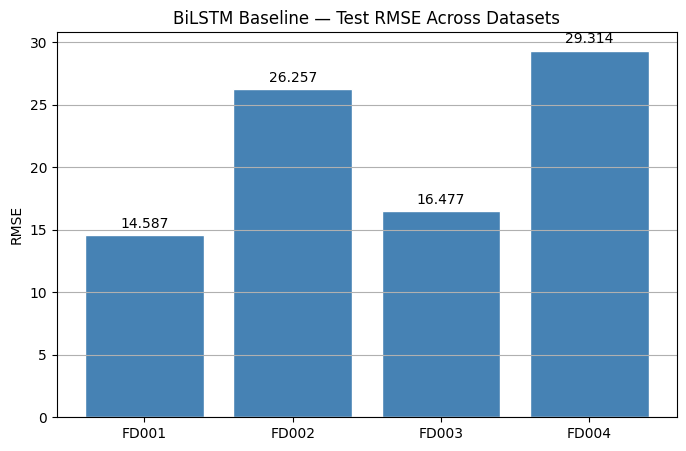


  HP: {'hidden': 64, 'num_heads': 4, 'key_dim': 32, 'dropout': 0.1, 'ffn_dim': 128, 'lr': 8e-05, 'batch_size': 32, 'epochs': 100, 'patience_es': 25, 'patience_lr': 8, 'lr_factor': 0.5, 'min_lr': 1e-07}


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# BiLSTM — SNIPPET 2: TRAINING + EVALUATION + BASELINE (PHASE 0)
# MODIFIED: Document 10's inline training loop converted to train_and_evaluate
# so the same code serves both the baseline run and Snippet 6's retrain.
# Phase 0 output is identical to running Document 10 directly.
# ══════════════════════════════════════════════════════════════════════════════
MODEL_NAME = 'BiLSTM'
DATASETS   = ['FD001','FD002','FD003','FD004']

def get_callbacks(hp):
    return [
        EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=hp['lr_factor'],
                          patience=hp['patience_lr'],
                          min_lr=hp['min_lr'], verbose=1)
    ]

def train_and_evaluate(dataset, hp, show_plots=True):
    """Full pipeline: load → preprocess → sequences → train → evaluate."""
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    train_raw, test_raw, y_test = load_data(dataset)
    train_df, test_df, feature_cols = preprocess(
        train_raw.copy(), test_raw.copy(), dataset)

    if show_plots:
        plot_rul_dist(train_df, dataset)

    eids             = train_df['id'].unique()
    tr_e, val_e      = train_test_split(eids, test_size=0.2, random_state=SEED)
    X_train, y_train = create_sequences(
        train_df[train_df['id'].isin(tr_e)], feature_cols, SEQ_LEN)
    X_val,   y_val   = create_sequences(
        train_df[train_df['id'].isin(val_e)], feature_cols, SEQ_LEN)
    X_test           = create_test_sequences(test_df, feature_cols, SEQ_LEN)
    nf               = X_train.shape[2]

    print(f"  Train:{X_train.shape} Val:{X_val.shape} Test:{X_test.shape}")

    model = build_bilstm(SEQ_LEN, nf, hp)
    hist  = model.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=hp['epochs'],
                      batch_size=hp['batch_size'],
                      callbacks=get_callbacks(hp),
                      verbose=0)

    vp = model.predict(X_val,  verbose=0).flatten()
    tp = model.predict(X_test, verbose=0).flatten()

    assert vp.shape == y_val.shape,  f"Val shape: {vp.shape}"
    assert tp.shape == y_test.shape, f"Test shape: {tp.shape}"

    print("\n  Validation:")
    report_metrics(f"  {MODEL_NAME}", y_val, vp)
    print("  Test:")
    r, m, ms, n = report_metrics(f"  {MODEL_NAME}", y_test, tp)

    if show_plots:
        plot_loss(hist, MODEL_NAME, dataset)
        plot_predictions(y_test, tp, MODEL_NAME, dataset)
        plot_residuals(y_test, tp, MODEL_NAME, dataset)

    return {'rmse': r, 'mae': m, 'mse': ms, 'nasa': n,
            'test_preds': tp, 'val_preds': vp,
            'y_test': y_test, 'y_val': y_val}

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 0 — BASELINE: default HP from Document 10, all 4 datasets
# ══════════════════════════════════════════════════════════════════════════════
all_results = {}

print(f"\n{'█'*55}")
print(f"  BiLSTM BASELINE — Default HP")
print(f"  hidden={HP_DEFAULT['hidden']}  num_heads={HP_DEFAULT['num_heads']}  "
      f"key_dim={HP_DEFAULT['key_dim']}  ffn_dim={HP_DEFAULT['ffn_dim']}")
print(f"  lr={HP_DEFAULT['lr']}  batch={HP_DEFAULT['batch_size']}  "
      f"dropout={HP_DEFAULT['dropout']}")
print(f"{'█'*55}")

for dataset in DATASETS:
    print(f"\n{'█'*55}\n  {MODEL_NAME} | {dataset}\n{'█'*55}")
    all_results[dataset] = train_and_evaluate(dataset, HP_DEFAULT)

print(f"\n{'═'*60}\n  {MODEL_NAME} BASELINE RESULTS\n{'═'*60}")
print(f"{'Dataset':<10} {'RMSE':>8} {'MAE':>8} {'MSE':>10} {'NASA':>10}")
print(f"{'':─<10} {'':─>8} {'':─>8} {'':─>10} {'':─>10}")
for ds in DATASETS:
    r = all_results[ds]
    print(f"{ds:<10} {r['rmse']:>8.3f} {r['mae']:>8.3f} "
          f"{r['mse']:>10.3f} {r['nasa']:>10.1f}")

avg = np.mean([all_results[ds]['rmse'] for ds in DATASETS])
print(f"\n  Average RMSE: {avg:.3f}")
plot_rmse_bar(all_results, f'{MODEL_NAME} Baseline')
print(f"\n  HP: {HP_DEFAULT}")

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# BiLSTM — SNIPPET 3 (NEW): SUBPROCESS WORKER + MEMORY-SAFE SEARCH HELPERS
#
# FIX FOR RAM CRASHES DURING BAYESIAN OPT:
#   - Every trial (Random AND Bayesian) trains in a FRESH subprocess.
#   - OS reclaims 100% of TF/Keras memory when the subprocess exits.
#   - Parent never holds a model, history, or training array during search.
#   - Arrays written to disk once; each worker reads via np.load (zero copy).
#   - _trim_ram() releases glibc heap pages between trials.
#   - smoke_test_worker() verifies the worker before burning the trial budget,
#     printing the FULL stderr on failure so the bug is immediately visible.
#
# NOTE: worker/array paths use bilstm_attn_* to avoid conflicts with the
# Deep BiLSTM (Wang et al.) files that use bilstm_* paths.
# ══════════════════════════════════════════════════════════════════════════════
import gc, optuna, subprocess, json, sys, os, ctypes
optuna.logging.set_verbosity(optuna.logging.WARNING)

WORKER_PATH  = '/tmp/bilstm_attn_worker.py'
ARRAY_PREFIX = '/tmp/bilstm_attn_arrays'

def _trim_ram():
    """Release glibc heap pages back to OS after large alloc/free cycles."""
    try: ctypes.cdll.LoadLibrary("libc.so.6").malloc_trim(0)
    except Exception: pass

# ── Worker script — complete self-contained BiLSTM+Attention trainer ──────────
# All HP values (hidden, ffn_dim, etc.) arrive as plain JSON scalars. ✓
# ffn Dense output dim computed explicitly as 2*hp['hidden'] — avoids relying
# on x.shape[-1] in a subprocess context where tracing behaviour can differ.
WORKER_CODE = r"""
import os, sys, json, numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS']       = 'ignore'
import warnings; warnings.filterwarnings('ignore')

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    except: pass

from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Dropout, Bidirectional,
    GlobalAveragePooling1D, LayerNormalization,
    MultiHeadAttention, Add)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

def build_bilstm(seq_len, n_features, hp):
    bilstm_out_dim = 2 * hp['hidden']   # explicit: avoids x.shape[-1] in subprocess
    inputs = Input(shape=(seq_len, n_features))
    x = Bidirectional(LSTM(hp['hidden'], return_sequences=True,
                           recurrent_dropout=0.0))(inputs)
    x = Dropout(hp['dropout'])(x)
    attn = MultiHeadAttention(num_heads=hp['num_heads'],
                               key_dim=hp['key_dim'],
                               dropout=0.05)(x, x)
    x   = LayerNormalization()(Add()([x, attn]))
    ffn = Dense(hp['ffn_dim'], activation='relu')(x)
    ffn = Dense(bilstm_out_dim)(ffn)
    x   = LayerNormalization()(Add()([x, ffn]))
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(hp['dropout'])(x)
    outputs = Dense(1)(x)
    m = Model(inputs, outputs)
    m.compile(optimizer=Adam(hp['lr'], clipnorm=1.0),
              loss=Huber(), metrics=['mae'])
    return m

hp     = json.loads(sys.argv[1])
prefix = sys.argv[2]
SEQ    = int(sys.argv[3])

X_tr  = np.load(f'{prefix}_Xtr.npy')
ytr   = np.load(f'{prefix}_ytr.npy')
X_val = np.load(f'{prefix}_Xval.npy')
yval  = np.load(f'{prefix}_yval.npy')

cbs = [
    EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=hp.get('patience_lr', 5), min_lr=1e-7)
]

try:
    m = build_bilstm(SEQ, X_tr.shape[2], hp)
    m.fit(X_tr, ytr, validation_data=(X_val, yval),
          epochs=hp['epochs'], batch_size=hp['batch_size'],
          callbacks=cbs, verbose=0)
    for cb in cbs:
        if hasattr(cb, 'best_weights'): cb.best_weights = None
    vp = m.predict(X_val, verbose=0).flatten()
    print(float(np.sqrt(mean_squared_error(yval, vp))))
    sys.exit(0)
except Exception:
    import traceback; traceback.print_exc(file=sys.stderr)
    sys.exit(1)
"""

def write_worker():
    with open(WORKER_PATH, 'w') as f:
        f.write(WORKER_CODE)
    print(f"  Worker written → {WORKER_PATH}")

def run_isolated(hp, timeout=300):
    """Spawns a fresh process per trial. OS reclaims all TF memory on exit."""
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH,
             json.dumps(hp), ARRAY_PREFIX, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
        if r.returncode == 0 and r.stdout.strip():
            return float(r.stdout.strip())
        if r.stderr:
            print(f"    [err] {r.stderr.strip()[-200:]}")
        return float('inf')
    except subprocess.TimeoutExpired:
        print(f"    [timeout {timeout}s]")
        return float('inf')
    except Exception as e:
        print(f"    [exc] {e}")
        return float('inf')

def smoke_test_worker(epochs_search=2, timeout=180):
    """One real subprocess trial; full stderr on fail so the bug is visible."""
    test_hp = {
        'hidden': 32, 'num_heads': 2, 'key_dim': 16,
        'dropout': 0.1, 'ffn_dim': 64,
        'lr': 1e-3, 'batch_size': 64,
        'epochs': epochs_search, 'patience_es': 5, 'patience_lr': 3,
    }
    print(f"\n  ── Smoke test: 1 subprocess trial ({epochs_search} epochs) ──")
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH,
             json.dumps(test_hp), ARRAY_PREFIX, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        print(f"  Smoke test TIMED OUT after {timeout}s"); return False

    if r.returncode == 0 and r.stdout.strip():
        print(f"  Smoke test OK — val RMSE: {float(r.stdout.strip()):.3f}")
        return True
    print(f"  Smoke test FAILED — full worker stderr:\n{r.stderr}")
    return False

def save_arrays(X_tr, ytr, X_val, yval):
    """Save precomputed arrays once; free from parent RAM for the whole search."""
    np.save(f'{ARRAY_PREFIX}_Xtr.npy',  X_tr)
    np.save(f'{ARRAY_PREFIX}_ytr.npy',  ytr)
    np.save(f'{ARRAY_PREFIX}_Xval.npy', X_val)
    np.save(f'{ARRAY_PREFIX}_yval.npy', yval)
    mb = (X_tr.nbytes + X_val.nbytes) / 1e6
    print(f"  Arrays saved to {ARRAY_PREFIX}_*.npy  ({mb:.0f} MB on disk)")

def _run_phase2(rs, n_bayes, top_n, objective_fn):
    """
    Ranks Phase-1 trials by val RMSE, takes top `top_n`, seeds a TPESampler
    study via add_trial (ZERO re-evaluation, ZERO GPU cost), then runs
    n_bayes new Bayesian trials around those promising regions.
    """
    sorted_t = sorted(rs.trials, key=lambda t: t.value)
    seeds    = [(t.params, t.distributions, t.value) for t in sorted_t[:top_n]]
    p1_best  = sorted_t[0].value
    del sorted_t; gc.collect()

    bs = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=top_n))

    for p, d, v in seeds:
        bs.add_trial(optuna.trial.create_trial(params=p, distributions=d, value=v))
    del seeds; gc.collect()

    print(f"  {top_n} seeds transferred (0 GPU). Running {n_bayes} new Bayesian trials...")

    def _cb(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        print(f"    Trial {trial.number+1:3d}: "
              f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")
        gc.collect(); _trim_ram()

    bs.optimize(objective_fn, n_trials=n_bayes, callbacks=[_cb])

    best = bs.best_trial
    print(f"\n  Phase1 best={p1_best:.3f}  Phase2 best={best.value:.3f}  "
          f"Δ={p1_best-best.value:+.3f}")

    try:
        imp = optuna.importance.get_param_importances(bs)
        plt.figure(figsize=(10, 4))
        plt.barh(list(imp.keys()), list(imp.values()), color='steelblue')
        plt.title('HP Importance — BiLSTM (Subprocess Bayesian)')
        plt.tight_layout(); plt.grid(axis='x'); plt.show()
    except Exception:
        pass
    return bs

print("BiLSTM subprocess worker + search helpers loaded.")

BiLSTM subprocess worker + search helpers loaded.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BiLSTM — SNIPPET 4 (NEW): COMBINED RANDOM + WARM-STARTED BAYESIAN SEARCH
#
# Search space:
#   hidden      : [32, 64, 128, 256]  — BiLSTM units; output = 2*hidden
#   num_heads   : [2, 4, 8]           — MHA heads (Keras projects internally;
#                                        no hard divisibility constraint)
#   key_dim     : [16, 32, 64]        — per-head key/query dimension
#   dropout     : [0.0, 0.4]          — applied after BiLSTM and final Dense
#   ffn_dim     : [64, 128, 256, 512] — FFN inner dimension
#   lr          : [1e-5, 1e-2] log    — Adam learning rate
#   batch_size  : [32, 64, 128]
#
# recurrent_dropout is kept at 0.0 (same as Document 10 default) — non-zero
# values disable the cuDNN LSTM kernel and cause ~5-10x slowdown per trial.
# ══════════════════════════════════════════════════════════════════════════════
def bilstm_combined_search(n_random=20, n_bayes=20, top_n=5,
                            dataset='FD001', epochs_search=40):
    print(f"\n{'═'*65}")
    print(f"  BiLSTM COMBINED SEARCH  |  {dataset}")
    print(f"  Phase1: Random {n_random}  |  Phase2: Bayesian {n_bayes} new trials "
          f"(seeded with top {top_n})")
    print(f"  Each trial = fresh subprocess → TF RAM fully reclaimed after exit")
    print(f"  Total subprocess evaluations: {n_random + n_bayes}")
    print(f"{'═'*65}")

    write_worker()

    # ── Precompute sequences ONCE; save to disk; free from parent RAM ──────────
    tr, _, _    = load_data(dataset)
    train_df, _, feat = preprocess(tr.copy(), tr.copy(), dataset)
    del tr
    eids        = train_df['id'].unique()
    tr_e, val_e = train_test_split(eids, test_size=0.2, random_state=SEED)
    X_tr,  ytr  = create_sequences(train_df[train_df['id'].isin(tr_e)],  feat, SEQ_LEN)
    X_val, yval = create_sequences(train_df[train_df['id'].isin(val_e)], feat, SEQ_LEN)
    del train_df
    save_arrays(X_tr, ytr, X_val, yval)
    del X_tr, ytr, X_val, yval   # parent holds zero arrays during search
    gc.collect(); _trim_ram()

    # ── Smoke test: fail fast before burning the trial budget ──────────────────
    if not smoke_test_worker(epochs_search=2):
        print("\n  ABORTING — fix WORKER_CODE / build_bilstm using traceback above.")
        return None, None, None

    # ── Objective: one subprocess per trial ────────────────────────────────────
    def objective(trial):
        hp = {
            'hidden'      : trial.suggest_categorical('hidden', [32, 64, 128, 256]),
            'num_heads'   : trial.suggest_categorical('num_heads', [2, 4, 8]),
            'key_dim'     : trial.suggest_categorical('key_dim', [16, 32, 64]),
            'dropout'     : trial.suggest_float('dropout', 0.0, 0.4),
            'ffn_dim'     : trial.suggest_categorical('ffn_dim', [64, 128, 256, 512]),
            'lr'          : trial.suggest_float('lr', 1e-5, 1e-2, log=True),
            'batch_size'  : trial.suggest_categorical('batch_size', [32, 64, 128]),
            'epochs'      : epochs_search,
            'patience_es' : 10,
            'patience_lr' : 4,
        }
        return run_isolated(hp)   # subprocess call — parent RAM stays flat

    # ── Phase 1: Random Search ──────────────────────────────────────────────────
    print(f"\n  ── Phase 1: Random Search ({n_random} trials) ──")
    rs = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.RandomSampler(seed=SEED))

    def _cb1(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        print(f"    Trial {trial.number+1:3d}: "
              f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")
        gc.collect(); _trim_ram()

    rs.optimize(objective, n_trials=n_random, callbacks=[_cb1])

    print(f"\n  Top {top_n} from Phase 1:")
    sorted_show = sorted(rs.trials, key=lambda t: t.value)
    for i, t in enumerate(sorted_show[:top_n]):
        p = t.params
        print(f"    #{i+1}  RMSE={t.value:.3f}  "
              f"hidden={p['hidden']}  num_heads={p['num_heads']}  "
              f"ffn_dim={p['ffn_dim']}  lr={p['lr']:.1e}")
    del sorted_show

    # ── Phase 2: Bayesian, warm-started with top-N Phase-1 seeds ───────────────
    print(f"\n  ── Phase 2: Bayesian ({n_bayes} new trials, seeded from Phase 1) ──")
    bs = _run_phase2(rs, n_bayes, top_n, objective)

    # ── Reconstruct best HP dict for full retraining ───────────────────────────
    p = bs.best_trial.params
    best_hp = {
        'hidden'      : p['hidden'],
        'num_heads'   : p['num_heads'],
        'key_dim'     : p['key_dim'],
        'dropout'     : p['dropout'],
        'ffn_dim'     : p['ffn_dim'],
        'lr'          : p['lr'],
        'batch_size'  : p['batch_size'],
        'epochs'      : 100,
        'patience_es' : 25,
        'patience_lr' : 8,
        'lr_factor'   : 0.5,
        'min_lr'      : 1e-7,
    }
    print(f"\n  Best HP: {best_hp}")
    return best_hp, rs, bs

print("BiLSTM combined search function loaded. Run Snippet 5 to start search.")

BiLSTM combined search function loaded. Run Snippet 5 to start search.



═════════════════════════════════════════════════════════════════
  BiLSTM COMBINED SEARCH  |  FD001
  Phase1: Random 20  |  Phase2: Bayesian 20 new trials (seeded with top 5)
  Each trial = fresh subprocess → TF RAM fully reclaimed after exit
  Total subprocess evaluations: 40
═════════════════════════════════════════════════════════════════
  Worker written → /tmp/bilstm_attn_worker.py
  Arrays saved to /tmp/bilstm_attn_arrays_*.npy  (67 MB on disk)

  ── Smoke test: 1 subprocess trial (2 epochs) ──
  Smoke test OK — val RMSE: 12.457

  ── Phase 1: Random Search (20 trials) ──
    Trial   1: 10.792 ← BEST
    Trial   2: 10.498 ← BEST
    Trial   3: 11.140 
    [timeout 300s]
    Trial   4: inf 
    Trial   5: 11.292 
    Trial   6: 10.597 
    Trial   7: 10.976 
    Trial   8: 11.528 
    Trial   9: 10.663 
    Trial  10: 11.085 
    Trial  11: 10.854 
    Trial  12: 10.435 ← BEST
    Trial  13: 10.946 
    Trial  14: 12.271 
    Trial  15: 10.853 
    Trial  16: 10.801 
    Trial  

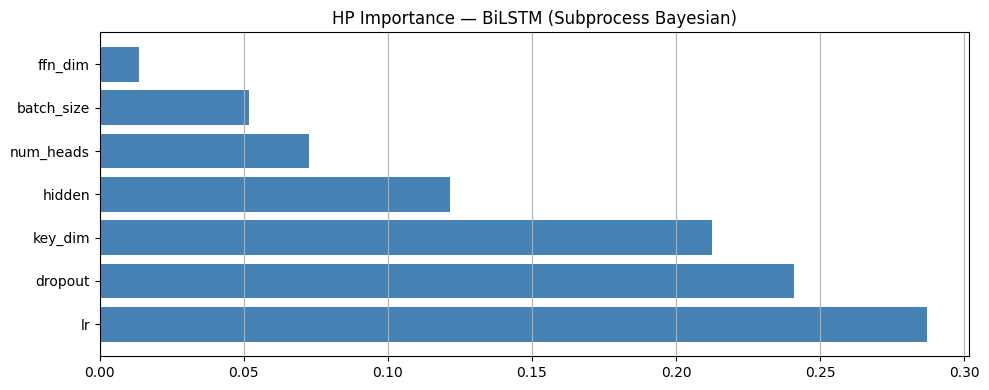


  Best HP: {'hidden': 256, 'num_heads': 2, 'key_dim': 64, 'dropout': 0.17870949176657944, 'ffn_dim': 256, 'lr': 0.004442562225062191, 'batch_size': 32, 'epochs': 100, 'patience_es': 25, 'patience_lr': 8, 'lr_factor': 0.5, 'min_lr': 1e-07}


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# BiLSTM — SNIPPET 5: RUN SEARCH
# ══════════════════════════════════════════════════════════════════════════════
best_hp_bilstm, rs_bilstm, bo_bilstm = bilstm_combined_search(
    n_random=20, n_bayes=20, top_n=5,
    dataset='FD001', epochs_search=60)


███████████████████████████████████████████████████████
  BiLSTM | FD001
███████████████████████████████████████████████████████


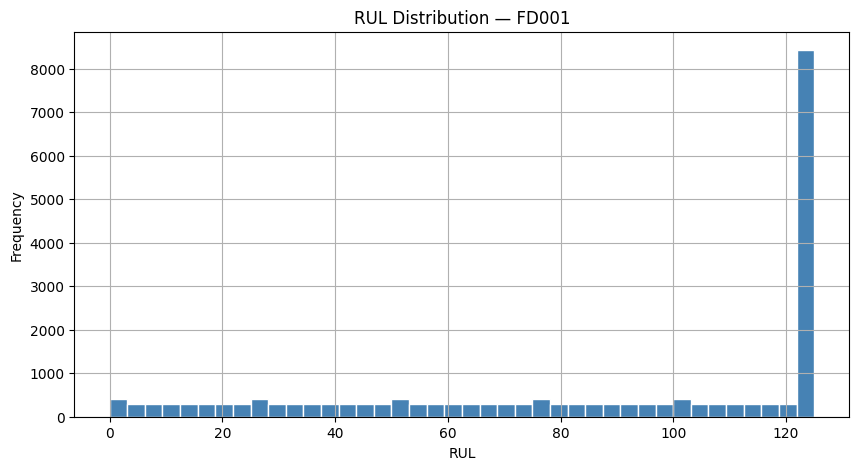

  Train:(13361, 40, 25) Val:(3270, 40, 25) Test:(100, 40, 25)

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.002221281174570322.

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.001110640587285161.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0005553202936425805.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.00027766014682129025.

  Validation:
  BiLSTM                                 MSE=118.340 RMSE=10.878 MAE=7.091 NASA=6692.5
  Test:
  BiLSTM                                 MSE=191.906 RMSE=13.853 MAE=9.791 NASA=342.3


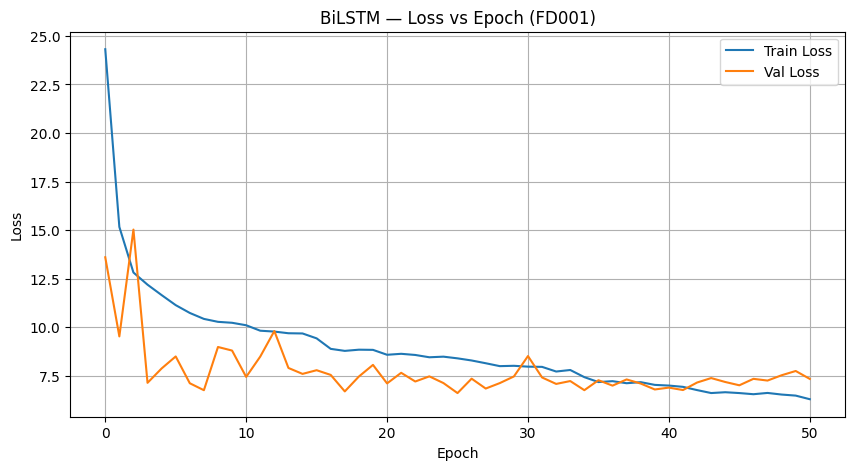

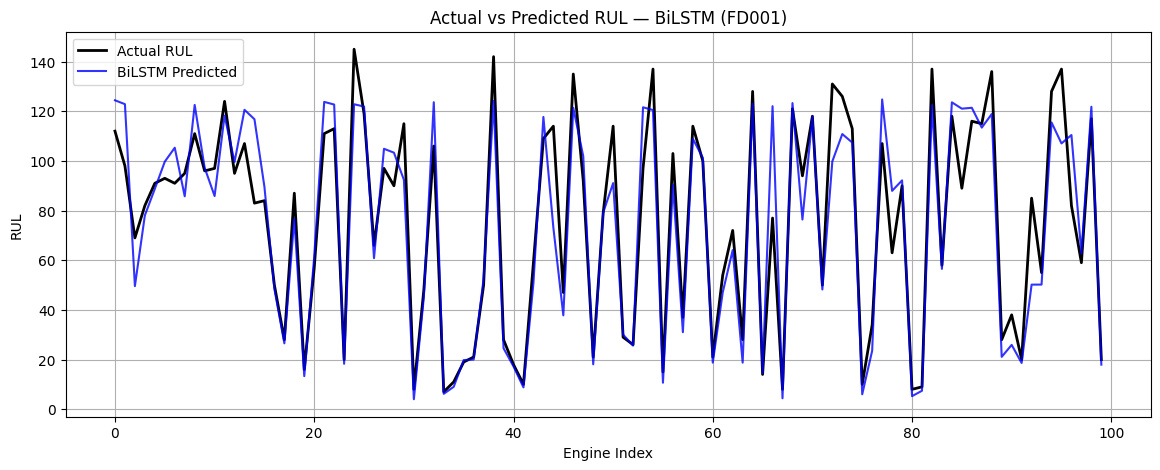

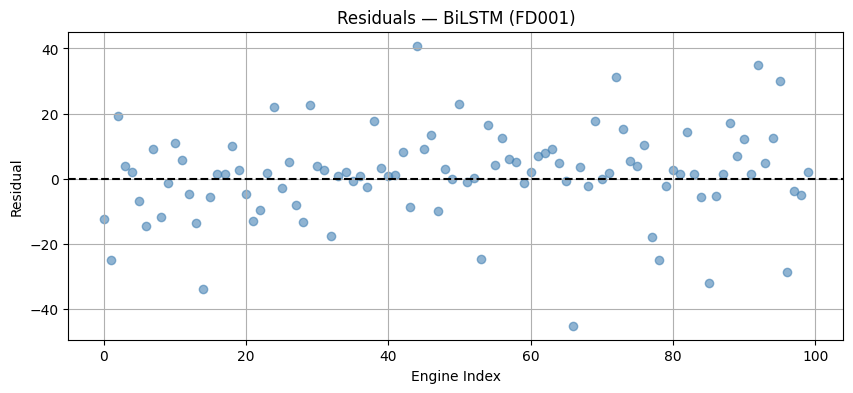


███████████████████████████████████████████████████████
  BiLSTM | FD002
███████████████████████████████████████████████████████


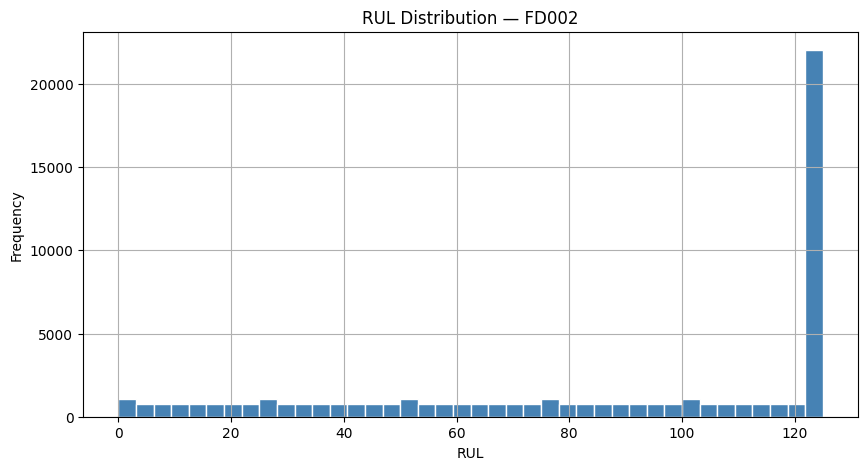

  Train:(35144, 40, 25) Val:(8215, 40, 25) Test:(259, 40, 25)

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.002221281174570322.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.001110640587285161.

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0005553202936425805.

  Validation:
  BiLSTM                                 MSE=414.171 RMSE=20.351 MAE=15.535 NASA=103940.1
  Test:
  BiLSTM                                 MSE=827.476 RMSE=28.766 MAE=21.671 NASA=9956.0


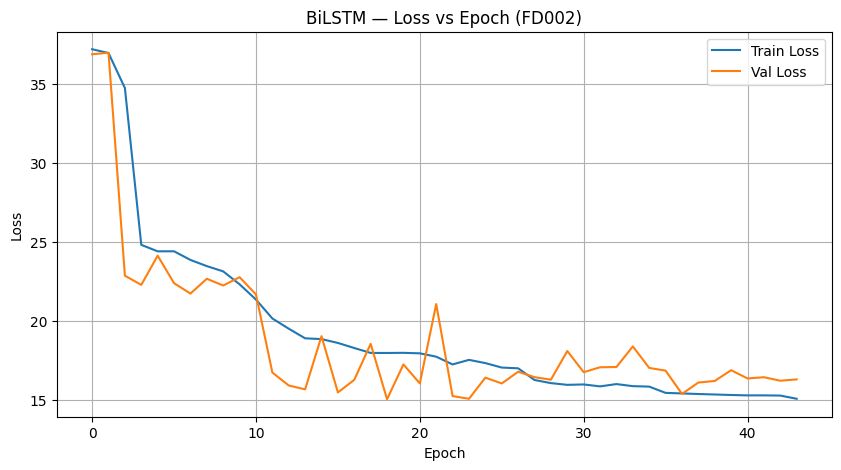

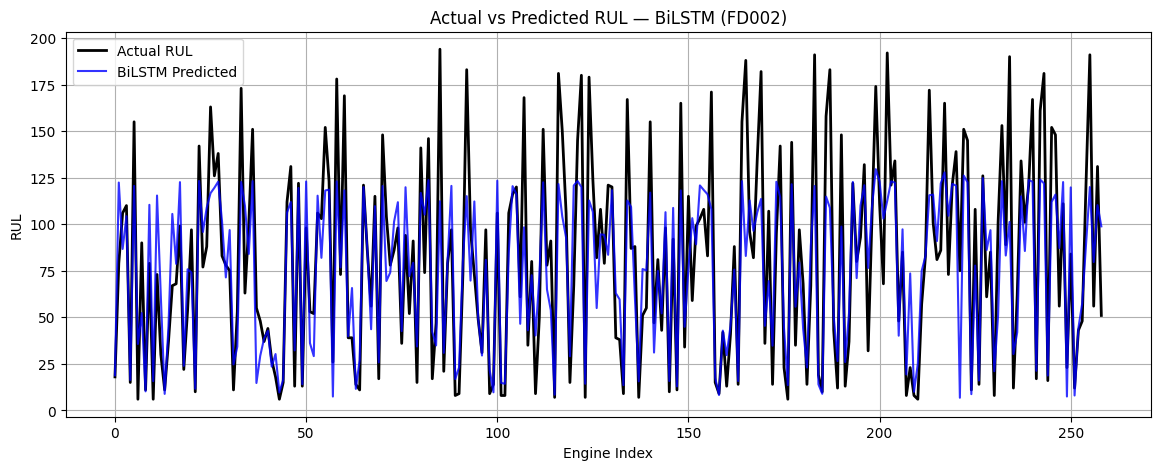

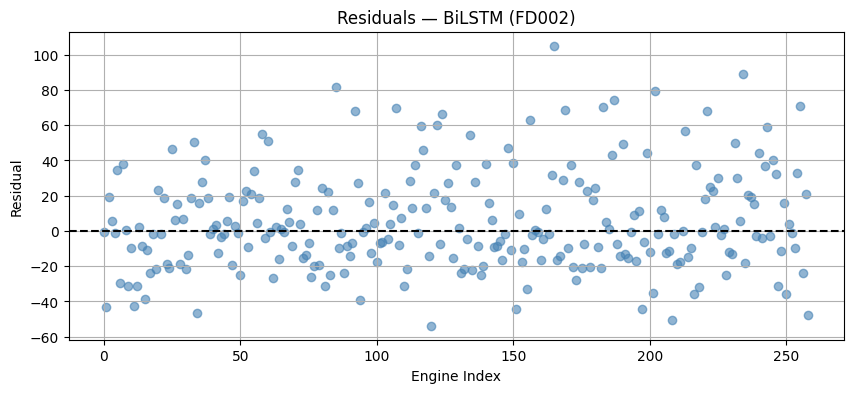


███████████████████████████████████████████████████████
  BiLSTM | FD003
███████████████████████████████████████████████████████


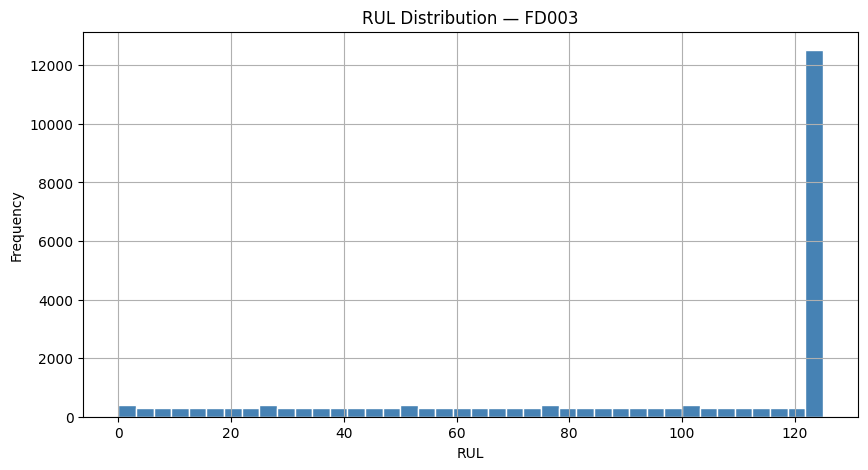

  Train:(16812, 40, 25) Val:(3908, 40, 25) Test:(100, 40, 25)

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.002221281174570322.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.001110640587285161.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.0005553202936425805.

Epoch 53: ReduceLROnPlateau reducing learning rate to 0.00027766014682129025.

  Validation:
  BiLSTM                                 MSE=84.318 RMSE=9.183 MAE=5.379 NASA=6085.1
  Test:
  BiLSTM                                 MSE=182.040 RMSE=13.492 MAE=9.197 NASA=456.6


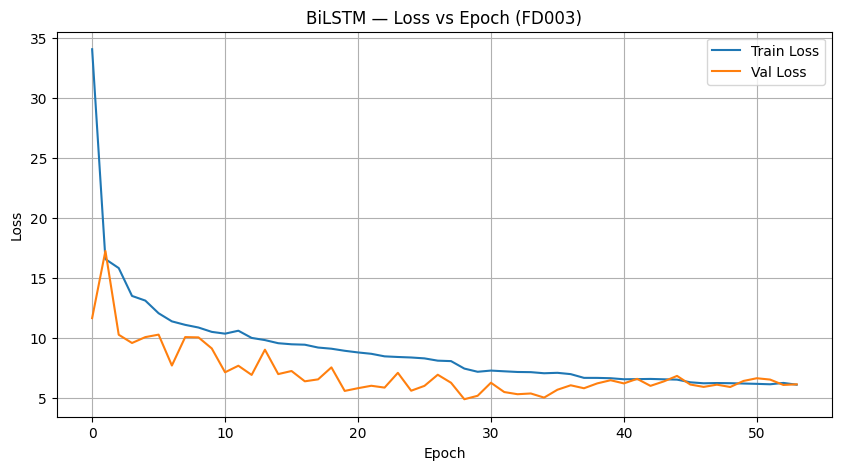

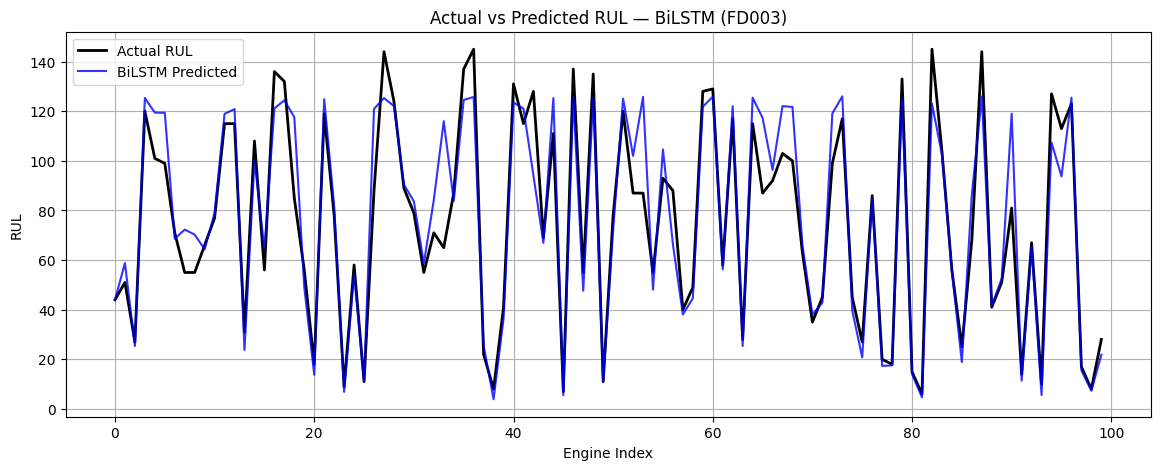

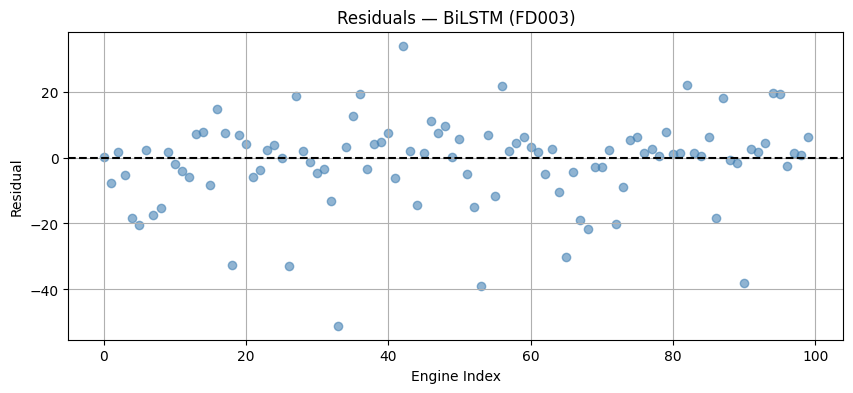


███████████████████████████████████████████████████████
  BiLSTM | FD004
███████████████████████████████████████████████████████


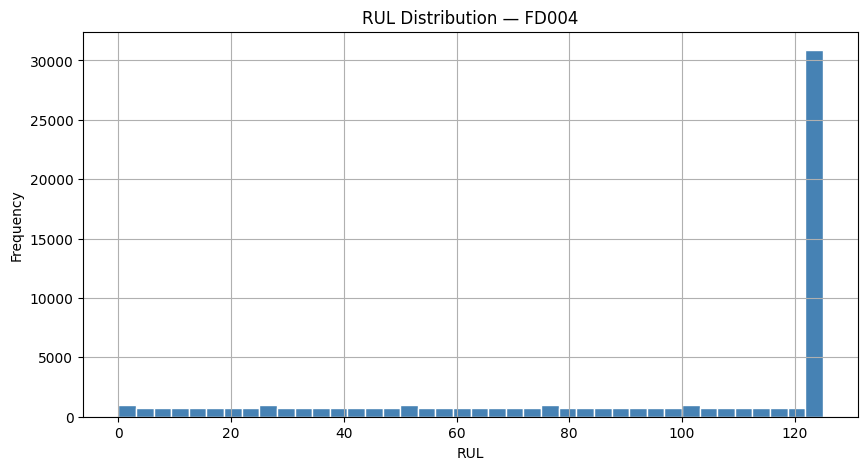

  Train:(41334, 40, 25) Val:(9955, 40, 25) Test:(248, 40, 25)

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.002221281174570322.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.001110640587285161.

Epoch 73: ReduceLROnPlateau reducing learning rate to 0.0005553202936425805.

  Validation:
  BiLSTM                                 MSE=517.984 RMSE=22.759 MAE=15.486 NASA=241602.6
  Test:
  BiLSTM                                 MSE=987.294 RMSE=31.421 MAE=24.576 NASA=10228.6


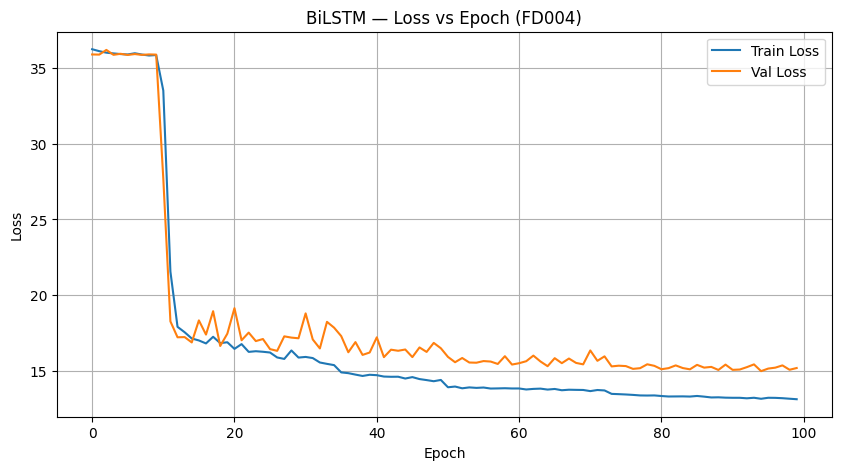

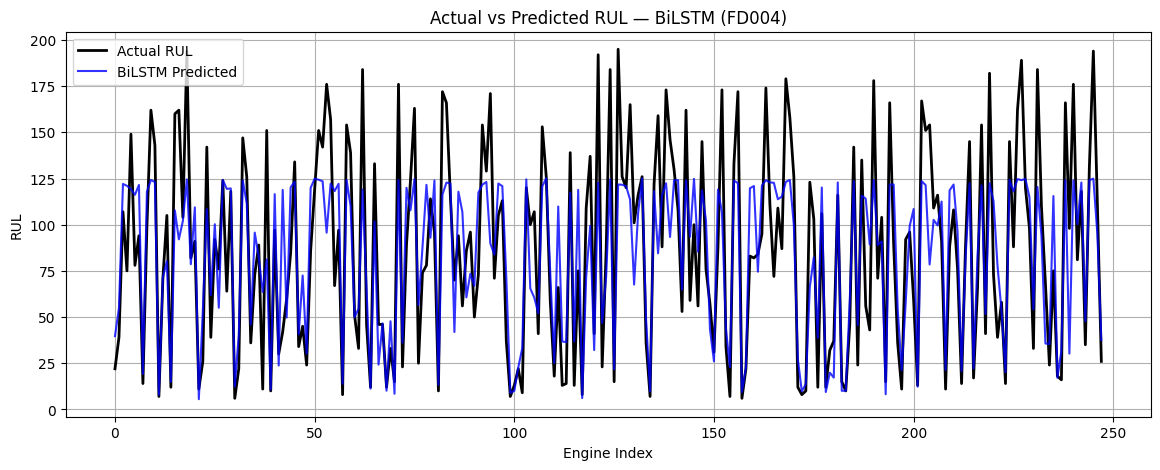

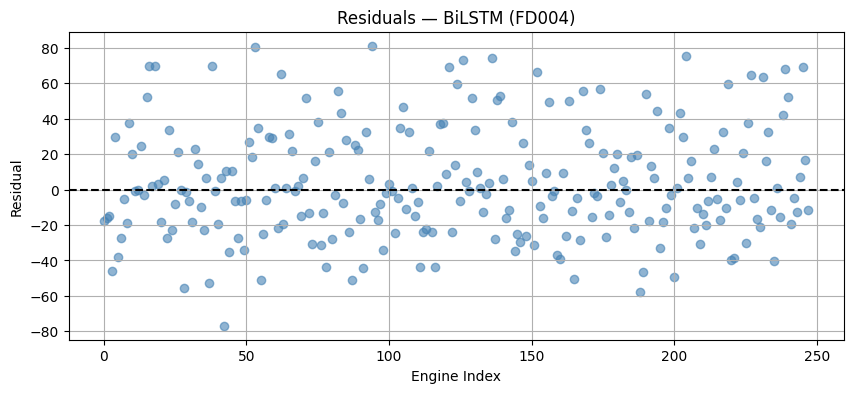


════════════════════════════════════════════════════════════
  BiLSTM OPTIMIZED RESULTS
════════════════════════════════════════════════════════════
Dataset        RMSE      MAE        MSE       NASA  vs Baseline
────────── ──────── ──────── ────────── ────────── ────────────
FD001        13.853    9.791    191.906      342.3       -0.734
FD002        28.766   21.671    827.476     9956.0       +2.509
FD003        13.492    9.197    182.040      456.6       -2.984
FD004        31.421   24.576    987.294    10228.6       +2.107

  Average RMSE: 21.883


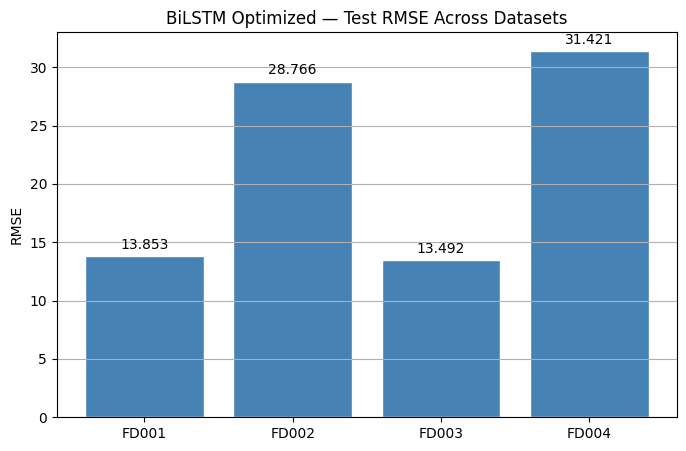


  HP: {'hidden': 256, 'num_heads': 2, 'key_dim': 64, 'dropout': 0.17870949176657944, 'ffn_dim': 256, 'lr': 0.004442562225062191, 'batch_size': 32, 'epochs': 100, 'patience_es': 25, 'patience_lr': 8, 'lr_factor': 0.5, 'min_lr': 1e-07}

  Predictions available for ensemble:
    FD001: test_preds.shape=(100,)  [min=4.0  max=124.8  mean=74.1]
    FD002: test_preds.shape=(259,)  [min=6.8  max=129.6  mean=75.9]
    FD003: test_preds.shape=(100,)  [min=3.9  max=126.0  mean=76.8]
    FD004: test_preds.shape=(248,)  [min=5.5  max=125.2  mean=83.0]

  Compatible with TCN, DATCN, DAST, and Deep BiLSTM predictions for weighted ensemble.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# BiLSTM — SNIPPET 6: RETRAIN BEST HP ON ALL 4 DATASETS
# NEW: explicit per-dataset memory cleanup (clear_session + gc + _trim_ram)
# prevents RAM accumulation across the 4 retrains. Only metrics and test_preds
# are kept — val_preds, y_val, y_test, and history freed after each dataset.
# ══════════════════════════════════════════════════════════════════════════════
optimized_bilstm = {}

for dataset in DATASETS:
    print(f"\n{'█'*55}\n  {MODEL_NAME} | {dataset}\n{'█'*55}")
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    try:
        result = train_and_evaluate(dataset, best_hp_bilstm, show_plots=True)
        # Keep only what we need — drop large array references immediately
        optimized_bilstm[dataset] = {
            'rmse'      : result['rmse'],
            'mae'       : result['mae'],
            'mse'       : result['mse'],
            'nasa'      : result['nasa'],
            'test_preds': result['test_preds'],
        }
        del result

    finally:
        # Per-dataset cleanup to keep RAM flat across all 4 retrains
        tf.keras.backend.clear_session()
        gc.collect(); gc.collect()
        _trim_ram()

print(f"\n{'═'*60}")
print(f"  {MODEL_NAME} OPTIMIZED RESULTS")
print(f"{'═'*60}")
print(f"{'Dataset':<10} {'RMSE':>8} {'MAE':>8} {'MSE':>10} "
      f"{'NASA':>10} {'vs Baseline':>12}")
print(f"{'':─<10} {'':─>8} {'':─>8} {'':─>10} {'':─>10} {'':─>12}")
for ds in DATASETS:
    o = optimized_bilstm[ds]
    b = all_results[ds]['rmse']
    print(f"{ds:<10} {o['rmse']:>8.3f} {o['mae']:>8.3f} "
          f"{o['mse']:>10.3f} {o['nasa']:>10.1f} {o['rmse']-b:>+12.3f}")

avg = np.mean([optimized_bilstm[ds]['rmse'] for ds in DATASETS])
print(f"\n  Average RMSE: {avg:.3f}")
plot_rmse_bar(optimized_bilstm, f'{MODEL_NAME} Optimized')

print(f"\n  HP: {best_hp_bilstm}")
print("\n  Predictions available for ensemble:")
for ds in DATASETS:
    tp = optimized_bilstm[ds]['test_preds']
    print(f"    {ds}: test_preds.shape={tp.shape}  "
          f"[min={tp.min():.1f}  max={tp.max():.1f}  mean={tp.mean():.1f}]")
print("\n  Compatible with TCN, DATCN, DAST, and Deep BiLSTM predictions for weighted ensemble.")